# Random Forest Model (With Automatic Tuning)



In [63]:
import os
import sys
import importlib
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

sys.path.append(os.path.abspath('..'))


import src.model_utils as model_utils
importlib.reload(model_utils)

evaluate_classifier = model_utils.evaluate_classifier
get_confusion_matrix_df = model_utils.get_confusion_matrix_df
load_encoded_splits = model_utils.load_encoded_splits
plot_metric_scorecards = model_utils.plot_metric_scorecards
plot_roc_curve = model_utils.plot_roc_curve
run_random_search = model_utils.run_random_search

In [64]:
DATA_DIR = '../data/'
X_train, y_train, X_val, y_val, X_test, y_test = load_encoded_splits(DATA_DIR)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}, y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')

Splits loaded successfully.
X_train: (60876, 32), y_train: (60876,)
X_val: (13045, 32), y_val: (13045,)
X_test: (13046, 32), y_test: (13046,)
X_train: (60876, 258), y_train: (60876,)
X_val:   (13045, 258), y_val:   (13045,)
X_test:  (13046, 258), y_test:  (13046,)


In [65]:
SEED = 42

base_rf = RandomForestClassifier(random_state=SEED, n_jobs=-1)

param_distributions = {
    'n_estimators': [80, 120, 160, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

search = run_random_search(
    estimator=base_rf,
    param_distributions=param_distributions,
    X_train=X_train,
    y_train=y_train,
    n_iter=8,
    cv=3,
    scoring='f1',
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
)

best_rf = search.best_estimator_
print('Best params:', search.best_params_)
print(f'Best CV f1: {search.best_score_:.4f}')

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'n_estimators': 120, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best CV f1: 0.6681


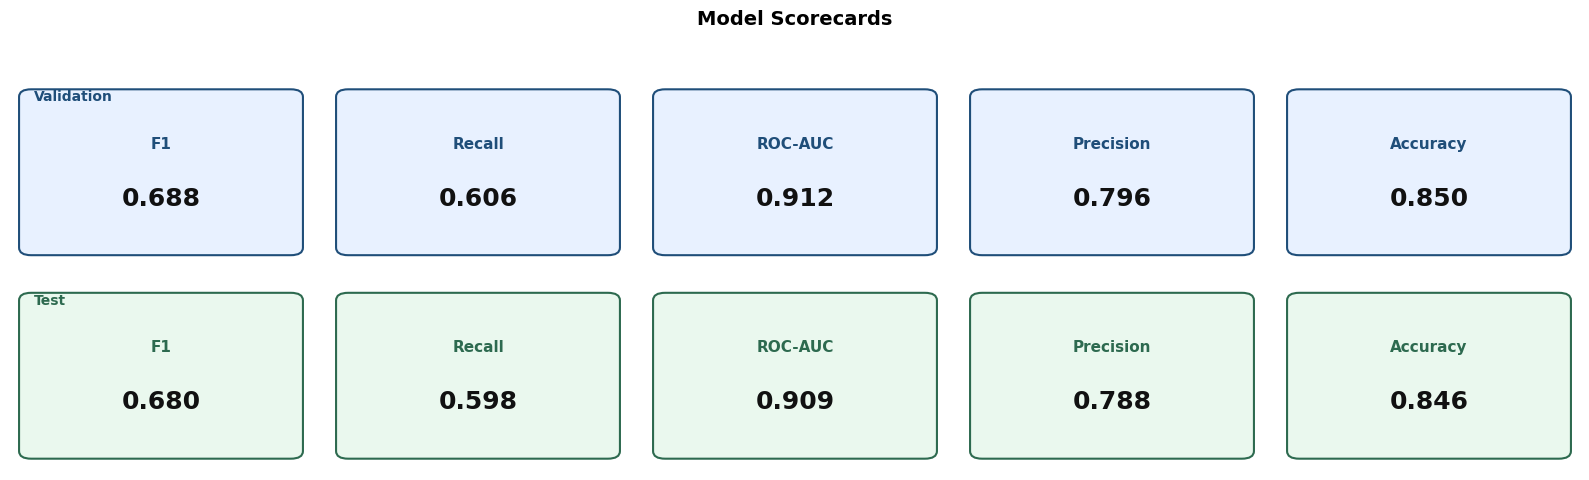

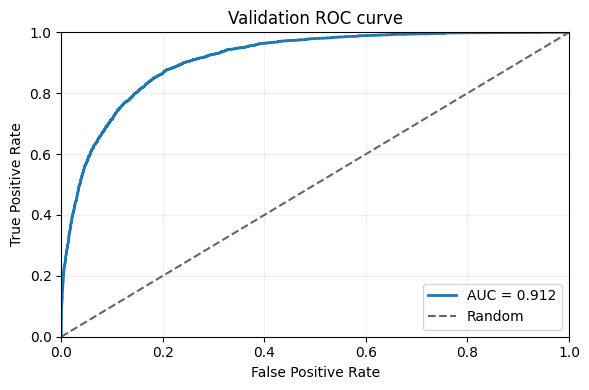

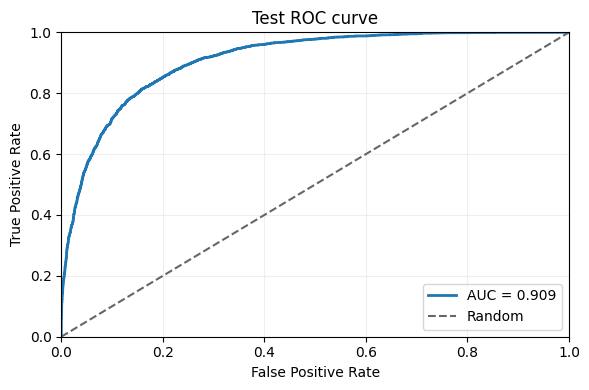

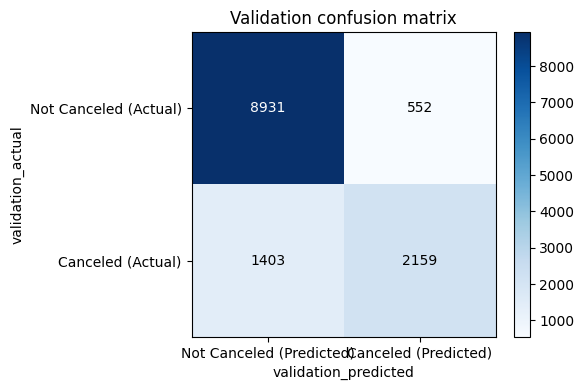

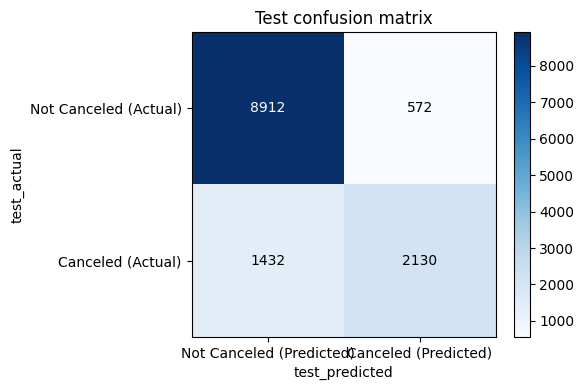

,split,accuracy,precision,recall,f1,roc_auc
0,validation,0.8501,0.7964,0.6061,0.6883,0.9121
1,test,0.8464,0.7883,0.5980,0.6801,0.9091


In [66]:
val_results = evaluate_classifier(best_rf, X_val, y_val, 'validation')
test_results = evaluate_classifier(best_rf, X_test, y_test, 'test')
plot_metric_scorecards(val_results, test_results)
plot_roc_curve(best_rf, X_val, y_val, 'validation')
plot_roc_curve(best_rf, X_test, y_test, 'test')
val_cm = get_confusion_matrix_df(best_rf, X_val, y_val, 'validation', plot=True)
test_cm = get_confusion_matrix_df(best_rf, X_test, y_test, 'test', plot=True)

results_df = pd.DataFrame([val_results, test_results])
display(results_df.round(4))

In [67]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_,
}).sort_values('importance', ascending=False)

display(importance_df.head(15))

,feature,importance
0,lead_time,0.106672
18,total_of_special_requests,0.067379
16,adr,0.061259
13,agent,0.058135
175,country_PRT,0.057040
2,arrival_date_week_number,0.040708
3,arrival_date_day_of_month,0.039058
17,required_car_parking_spaces,0.036372
224,market_segment_Online TA,0.035782
19,total_nights,0.030677
